### LOADING AND CONFIG

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import load_model
import os
import joblib

DATA_PATH = r'D:\PJT2\CMAPSSData' 
BASE_PATH = r'D:\PJT2\telemetryDataset'
PROCESSED_PATH = os.path.join(BASE_PATH, 'processed_data')
MODEL_PATH = r'./model_checkpoints'

### ATTENTION LAYER 

In [18]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

### LOADING MODELS AND TEST DATA

In [19]:
feature_scaler = joblib.load(os.path.join(PROCESSED_PATH, 'fd003_feature_scaler.pkl'))
signature_scaler = joblib.load(os.path.join(PROCESSED_PATH, 'fd003_signature_scaler.pkl'))
router_model = joblib.load(os.path.join(PROCESSED_PATH, 'fd003_router_model.pkl'))

model_c0 = load_model(os.path.join(MODEL_PATH, 'specialist_0_fd003.keras'), custom_objects={'Attention': Attention})
model_c1 = load_model(os.path.join(MODEL_PATH, 'specialist_1_fd003.keras'), custom_objects={'Attention': Attention})

lstm_features = feature_scaler.feature_names_in_.tolist()
router_features = signature_scaler.feature_names_in_.tolist()

### SETTING UP TEST FEATURES 

In [20]:
print("Preparing Test Data...")
cols = ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's{i}' for i in range(1, 22)]
test_df = pd.read_csv(os.path.join(DATA_PATH, 'test_FD003.txt'), sep='\s+', header=None, names=cols)
true_ruls = pd.read_csv(os.path.join(DATA_PATH, 'RUL_FD003.txt'), header=None, names=['RUL'])
raw_test_df = test_df.copy()

test_df[lstm_features] = feature_scaler.transform(test_df[lstm_features])
test_df[lstm_features] = test_df.groupby('unit_number')[lstm_features].transform(lambda x: x.ewm(alpha=0.1).mean())

Preparing Test Data...


### ROUTING AND PREDICTING

In [21]:
final_predictions, actuals = [], []
routed_counts = {0: 0, 1: 0}
WINDOW_SIZE = 30
sensor_cols = [f's{i}' for i in range(1, 22)]

for unit_id in test_df['unit_number'].unique():
    unit_data = test_df[test_df['unit_number'] == unit_id]
    
    if len(unit_data) >= WINDOW_SIZE:
        # Ask the Router
        raw_tail = raw_test_df[raw_test_df['unit_number'] == unit_id][sensor_cols].tail(5).mean().to_frame().T
        sig_scaled = signature_scaler.transform(raw_tail[router_features])
        assigned_cluster = router_model.predict(sig_scaled)[0]
        routed_counts[assigned_cluster] += 1
        
        seq = unit_data[lstm_features].values[-WINDOW_SIZE:].reshape(1, WINDOW_SIZE, len(lstm_features))
        
        pred = model_c0.predict(seq, verbose=0)[0][0] if assigned_cluster == 0 else model_c1.predict(seq, verbose=0)[0][0]
            
        final_predictions.append(pred)
        actuals.append(true_ruls.iloc[unit_id-1].values[0])

### FINAL EVALUATION

In [22]:
final_rmse = np.sqrt(np.mean((np.array(final_predictions) - np.array(actuals)) ** 2))

print("\n" + "="*50)
print(f"Routed to Specialist 0: {routed_counts[0]}")
print(f"Routed to Specialist 1: {routed_counts[1]}")
print("-" * 30)
print(f"GLOBAL MODEL RMSE (Baseline): 21.04")
print(f"MIXTURE OF EXPERTS RMSE (Final): {final_rmse:.4f}")
print("="*50)


Routed to Specialist 0: 57
Routed to Specialist 1: 43
------------------------------
GLOBAL MODEL RMSE (Baseline): 21.04
MIXTURE OF EXPERTS RMSE (Final): 20.2491


### VISUALISING

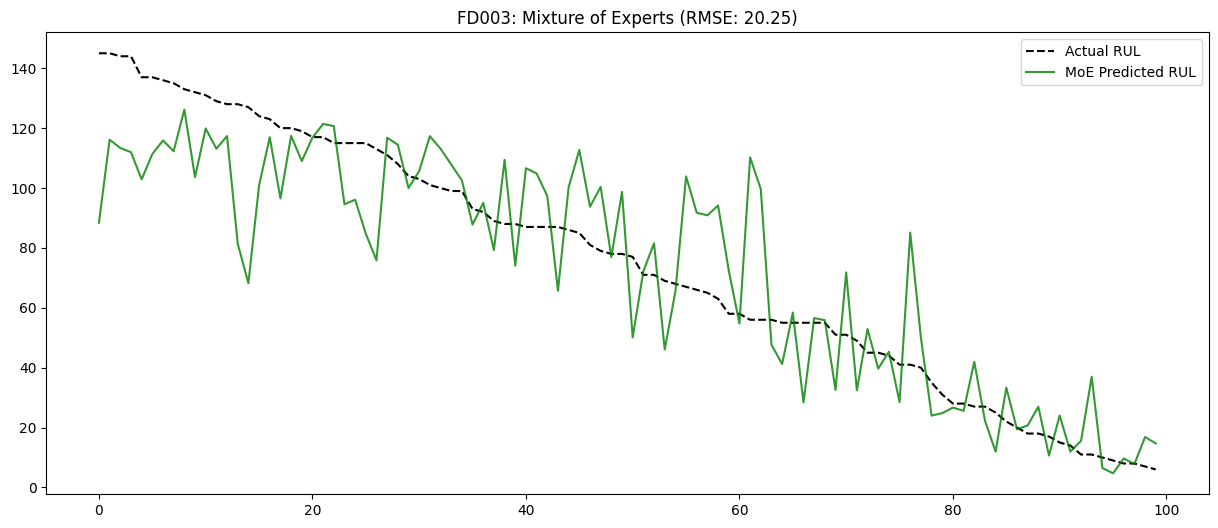

In [23]:
results_df = pd.DataFrame({'True': actuals, 'Pred': final_predictions}).sort_values('True', ascending=False).reset_index(drop=True)
plt.figure(figsize=(15, 6))
plt.plot(results_df['True'], label='Actual RUL', color='black', linestyle='--')
plt.plot(results_df['Pred'], label='MoE Predicted RUL', color='green', alpha=0.8)
plt.title(f'FD003: Mixture of Experts (RMSE: {final_rmse:.2f})')
plt.legend()
plt.show()

### SAVING

In [24]:
results_save_path = r'./fd003_moe_final_predictions.csv'

results_df.to_csv(results_save_path, index=False)

print(f"Final predictions successfully saved to: {os.path.abspath(results_save_path)}")

Final predictions successfully saved to: D:\PJT2\telemetryDataset\models\fault_specific\FD003\fd003_moe_final_predictions.csv
